In [1]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy import integrate
from copy import deepcopy

# cloelib imports
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations
from cloelib.observables.photo import ShearTracer, PositionsTracer
from cloelib.summary_statistics.angular_two_point import AngularTwoPoint
from cloelib.summary_statistics.angular_correlation_function_wigner import AngularCorrelationFunctionWigner

import euclidlib as el

# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=14)

/Users/s2265800/miniforge3/envs/cloe-org-env-v2026.1/lib/python3.12/site-packages/HMcode2020Emu
Loading linear emulator...
Linear emulator loaded in memory.
Loading nonlinear emulator...
Non-linear emulator loaded in memory.
Loading linear emulator...
Baryonic boost emulator loaded in memory.
Loading sigma8 emulator...
Linear emulator loaded in memory.


In [2]:
from cloelib.cosmology.MGrowth_cosmology import MGrowthLinearPerturbations


# Download all necessary components for the null-tests on ΛCDM

In [3]:
# Execute this cell to download the data for testing the likelihood calculations
data_downloaded = True

if data_downloaded == False:
    
    import requests
    
    # URLs of the files to be downloaded
    urls = {
        'nz_example.fits': 'https://zenodo.org/records/15092862/files/nz_example.fits',
        'cov_Gauss_3x2pt_2D_probe_zpair_ell_2500deg2_ellmax5000_Bmode_copy.npy': 'https://zenodo.org/records/15496892/files/cov_Gauss_3x2pt_2D_probe_zpair_ell_2500deg2_ellmax5000_Bmode_copy.npy',
        'mixmat_identity_5000_binned.fits': 'https://zenodo.org/records/15496892/files/mixmat_identity_5000_binned.fits',
        'synth_cells_5000_binned.fits': 'https://zenodo.org/records/15496892/files/synth_cells_5000_binned.fits',
    }
    
    # Function to download a file
    def download_file(url, filename):
        response = requests.get(url)
        if response.status_code == 200:
            with open(filename, 'wb') as f:
                f.write(response.content)
            print(f'{filename} downloaded successfully')
        else:
            print(f'Failed to download {filename}. Status code: {response.status_code}')
    
    # Download all files
    for filename, url in urls.items():
        download_file(url, filename)

## Cosmology: Background and Linear Perturbations

This code snippet initializes and computes the cosmological background and perturbations at various redshifts using the **CAMB**, **HMCode2020Emu** and **MGrowth** interfaces.

Implemented models include

* Hu-Sawicki f(R) gravity: gravity_model='fr' and 'fr0' $=|f_{R0}|$ ;
* Normal branch of DGP: gravity_model='dgp' and 'omega_rc' $=\Omega_{rc}$ ;
* Dark Scttering model: gravity_model='ide' and 'xi' $=\xi = (1+w)A_{\rm ds}$ ;
* Growth index parametrisation: gravity_model='gamma' and 'gamma' $=\gamma$ ;
* Time-dependent growth index parametrisation $\gamma(z)=\gamma_0+\gamma_1\frac{z^2}{1+z}$: gravity_model='gammaz' and 'gamma0' $=\gamma_0$, 'gamma1' $=\gamma_1$ ; 
* Generalised parametrisation with the dark energy evolution $\Xi(a)=1+\Xi_0\frac{\Omega_{\rm DE}(z)}{\Omega_{\rm DE}(0)}$ for $\Xi = \{\mu, \Sigma\}$: gravity_model='musigma-de' and mu0 $=\mu_0$, sigma0 $=\Sigma_0$.

We read extended parameters as a dictionary for the following reasons:

* generalised binned models might include $\mathcal{O}(10)$ parameters
* for sampling it is easier to input a specific MG parameters in an ini-file, instead of some mysterious MGp (a disadvantage here: the user must follow the convention for the variables' names)

In [4]:
zs = np.linspace(1e-4, 3, 100)

# The arguments of the Background functions follow the cosmology.API
background = CAMBBackground(H0=67.0, 
                            Omega_cdm0=0.27, 
                            Omega_b0=0.049, 
                            w0=-1, 
                            wa=0, 
                            Omega_k0 = 0.0, 
                            ns = 0.96, 
                            As = 2.1e-9,
                            mnu = 0.0001,
                            gamma_MG = 0.545,
                            N_mnu = 1)
linear_perturbations_emu = HMemuLinearPerturbations(background, zs)

mgpars_example = {
    'mu0': 0.4,
    'sigma0': 0.,
    'omega_rc': 0.25, 
    'fr0': 1.e-5,
    'xi': 6., # requires modification of the backround to w!=-1
    'gamma0': 0.55, #growth index
    'gamma1': 0.
}


linear_perturbations_gamma = MGrowthLinearPerturbations(background, linear_perturbations_emu,
                                                        gravity_model='gammaz',
                                                        mgpars=mgpars_example 
                                                        )


linear_perturbations_dgp = MGrowthLinearPerturbations(background, linear_perturbations_emu,
                                                      gravity_model='dgp',
                                                      mgpars=mgpars_example 
                                                      )


linear_perturbations_fr = MGrowthLinearPerturbations(background, linear_perturbations_emu,
                                                     gravity_model='fr',
                                                     mgpars=mgpars_example 
                                                     )


linear_perturbations_mu = MGrowthLinearPerturbations(background, linear_perturbations_emu,
                                                     gravity_model='musigma-de',
                                                     mgpars=mgpars_example 
                                                     )


In [5]:
print(linear_perturbations_emu.sigma8_0())
print(linear_perturbations_gamma.sigma8_0())
print(linear_perturbations_dgp.sigma8_0())
print(linear_perturbations_fr.sigma8_0())
print(linear_perturbations_mu.sigma8_0())

0.8280027109334782
0.827910349871425
0.8858972817853668
1.1188593051950713
0.8699876339473177


# Call the linear power spectrum 

In [6]:
ks = np.logspace(np.log10(1e-3), np.log10(2), 100)
ps_lcdm = linear_perturbations_emu.matter_power_spectrum(0, ks)
ps_gamma = linear_perturbations_gamma.matter_power_spectrum(0, ks)
ps_dgp = linear_perturbations_dgp.matter_power_spectrum(0, ks)
ps_fr = linear_perturbations_fr.matter_power_spectrum(0, ks)
ps_mu = linear_perturbations_mu.matter_power_spectrum(0, ks)

<>:8: SyntaxWarning: invalid escape sequence '\L'
<>:8: SyntaxWarning: invalid escape sequence '\L'
/var/folders/h4/nm88s1d55cb19yw7pxm0tzs40000gn/T/ipykernel_67455/996140096.py:8: SyntaxWarning: invalid escape sequence '\L'
  plt.ylabel('$P(k, z=0)/P_{\Lambda CDM}$', fontsize = 16)


Text(0.5, 1.0, 'Ratio')

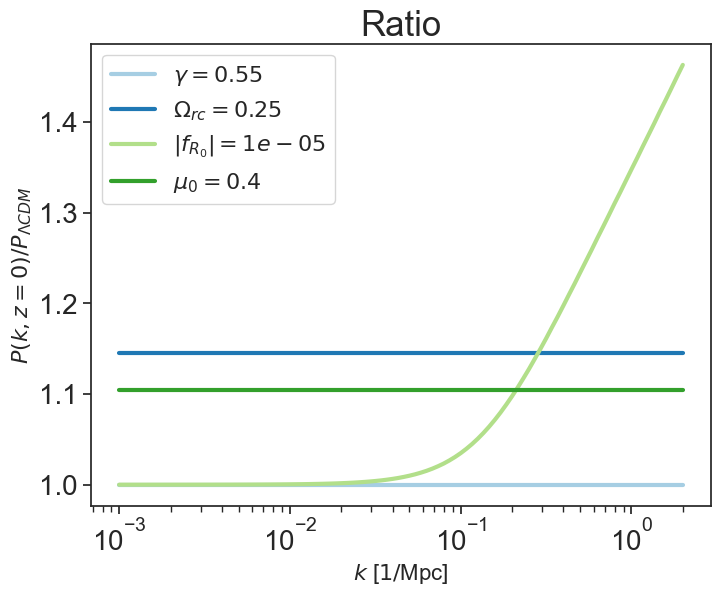

In [7]:
# Create the figure
plt.figure(figsize=(8, 6))
plt.semilogx(ks, ps_gamma[0]/ps_lcdm[0], label=f"$\\gamma={mgpars_example['gamma0']}$")
plt.semilogx(ks, ps_dgp[0]/ps_lcdm[0], label=f"$\\Omega_{{rc}}={mgpars_example['omega_rc']}$")
plt.semilogx(ks, ps_fr[0]/ps_lcdm[0], label=f"$|f_{{R_0}}|={mgpars_example['fr0']}$")
plt.semilogx(ks, ps_mu[0]/ps_lcdm[0], label=f"$\\mu_0={mgpars_example['mu0']}$")
plt.xlabel('$k$ [$1/$Mpc]', fontsize = 16)
plt.ylabel('$P(k, z=0)/P_{\Lambda CDM}$', fontsize = 16)
plt.legend(fontsize = 16)
plt.title("Ratio")

# Compute $C_\ell$ for cosmic shear

Set-up: 6 redshift bins, both sources and lenses follow the same distribution

In [8]:
# Get n(z)
#z_nz, nz_heracles = el.photo.redshift_distributions('nz_example.fits')
z_nz, nz_heracles = el.phz.redshift_distributions('nz_example.fits')

# Normalize and resample n(z) for both position and shear
myz = np.linspace(1e-4, 3.0, 100)
def normalize_and_resample(nz_dict, z_grid, z_target):
    nz_array = np.vstack([nz / integrate.trapezoid(nz, z_grid) for nz in nz_dict.values()])
    return np.array([np.interp(z_target, z_grid, nz) for nz in nz_array])

my_dndz_pos_norm = normalize_and_resample(nz_heracles, z_nz, myz)
my_dndz_she_norm = normalize_and_resample(nz_heracles, z_nz, myz)


In [9]:
shear_nuisance = {
                  'AIA': 0.16, 'CIA': 0.0134, 'EtaIA':1.66,
                'multiplicative_bias_1': 0.00, 'multiplicative_bias_2': 0.00,
                'multiplicative_bias_3': 0.00, 'multiplicative_bias_4': 0.00,
                'multiplicative_bias_5': 0.00, 'multiplicative_bias_6': 0.00,
                'dz_shear_1': 0.000, 'dz_shear_2': 0.000,
                'dz_shear_3': 0.000, 'dz_shear_4': 0.000,
                'dz_shear_5': 0.000, 'dz_shear_6': 0.000,
                'width_shear_1': 1.0, 'width_shear_2': 1.0,
                'width_shear_3': 1.0, 'width_shear_4': 1.0,
                'width_shear_5': 1.0, 'width_shear_6': 1.0
}

In [10]:
labels = ['emu', 'gamma',  'dgp', 'fr', 'mu']
cells_shear = {}
nl = 100
ells = np.logspace(1., np.log10(3000), nl)

# WARNING: SCALE-DEPENDENCE IN THE LENSING KERNELS IS NOT IMPLEMENTED YET!
In other words, the scale-dependent growth factor in the IA kenrel for $f(R)$ is computed at a fixed $k$ in the linear regime (making it effectively GR). Also scale-dependent $\Sigma(z, k)$ is not availbale yet. 

In [11]:
for label in labels:
    perturbations = eval(f'linear_perturbations_{label}')
    tracer_she = ShearTracer(perturbations=perturbations, 
                                dndz=my_dndz_she_norm,
                                z = zs,
                                nuisance_params=shear_nuisance)
    twopoint_sheshe = AngularTwoPoint(tracer_she, tracer_she)
    print(label)
    cells_EE = twopoint_sheshe.get_Cl(ells, 0, linear_perturbations_emu.k)
    cells_shear[label] = cells_EE

emu
gamma
dgp
fr
mu


<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\e'
/var/folders/h4/nm88s1d55cb19yw7pxm0tzs40000gn/T/ipykernel_67455/3716179276.py:16: SyntaxWarning: invalid escape sequence '\e'
  fig.legend(labels+['$\ell_{\\rm max}=200$', '$\ell_{\\rm max}=500$', '$\ell_{\\rm max}=1500$'],  loc='upper right', ncol=1, bbox_to_anchor=(1, 0.93), bbox_transform=fig.transFigure, fontsize=20, frameon=False, title_fontsize=20)
/var/folders/h4/nm88s1d55cb19yw7pxm0tzs40000gn/T/ipykernel_67455/3716179276.py:16: SyntaxWarning: invalid escape sequence '\e'
  fig.legend(labels+['$\ell_{\\rm max}=200$', '$\ell_{\\rm max}=500$', '$\ell_{\\rm max}=1500$'],  loc='upper right', ncol=1, bbox_to_anchor=(1, 0.93), bbox_transform=fig.transFigure, fontsize=20, frameon=Fals

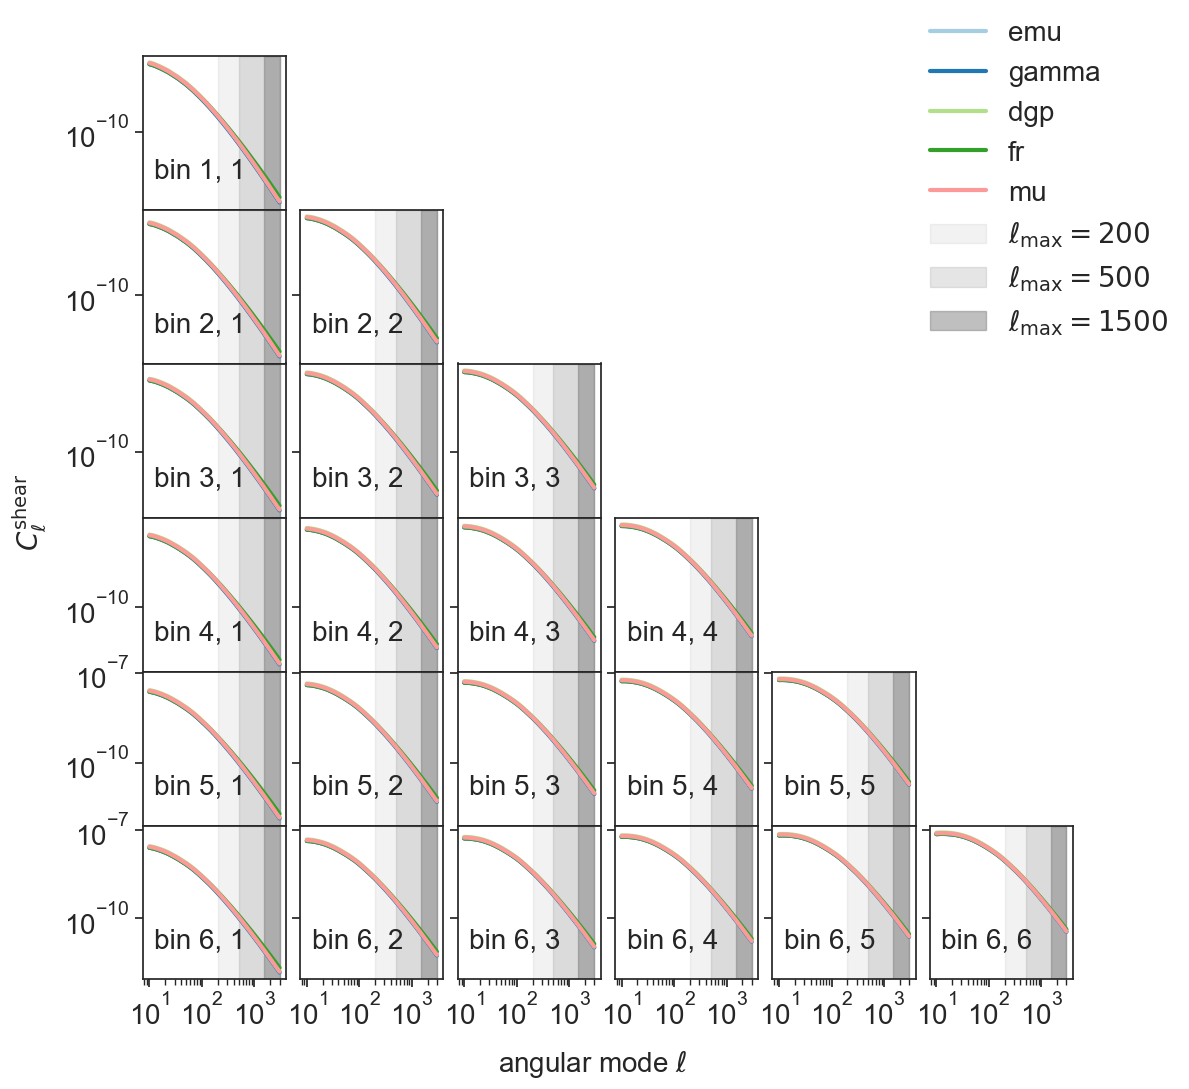

In [12]:
nbin = 6
fig, ax = plt.subplots(nbin, nbin, figsize=(12, 12), sharey='row', sharex=True, gridspec_kw={'wspace': 0.1, 'hspace': 0})
for i in range(nbin):
    for j in range(nbin):
        if i >= j:
            for label in labels:
                ax[i,j].loglog(ells,  cells_shear[label][('SHE', 'SHE', j+1, i+1)][0, 0])
            ax[i,j].text(.4, .2, 'bin %s, %s'%(str(i+1),(j+1)), fontsize="medium", horizontalalignment='center', transform=ax[i,j].transAxes)
            ax[i, j].axvspan(xmin=200, xmax=ells[-1], color='grey', alpha=0.1)
            ax[i, j].axvspan(xmin=500, xmax=ells[-1], color='grey', alpha=0.2)
            ax[i, j].axvspan(xmin=1500, xmax=ells[-1], color='grey', alpha=0.5)
        else:
            ax[i,j].axis('off')       
fig.text(0.03, 0.5, r'$C^{\rm shear}_{\ell}$', ha='center', va='center', rotation='vertical', fontsize=20)
fig.text(0.5, 0.04, r'angular mode $\ell$', ha='center', va='center', fontsize=20)   
fig.legend(labels+['$\ell_{\\rm max}=200$', '$\ell_{\\rm max}=500$', '$\ell_{\\rm max}=1500$'],  loc='upper right', ncol=1, bbox_to_anchor=(1, 0.93), bbox_transform=fig.transFigure, fontsize=20, frameon=False, title_fontsize=20)


<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\e'
/var/folders/h4/nm88s1d55cb19yw7pxm0tzs40000gn/T/ipykernel_67455/4289783292.py:16: SyntaxWarning: invalid escape sequence '\e'
  fig.legend(labels+['$\ell_{\\rm max}=200$', '$\ell_{\\rm max}=500$', '$\ell_{\\rm max}=1500$'],  loc='upper right', ncol=1, bbox_to_anchor=(1, 0.93), bbox_transform=fig.transFigure, fontsize=20, frameon=False, title_fontsize=20)
/var/folders/h4/nm88s1d55cb19yw7pxm0tzs40000gn/T/ipykernel_67455/4289783292.py:16: SyntaxWarning: invalid escape sequence '\e'
  fig.legend(labels+['$\ell_{\\rm max}=200$', '$\ell_{\\rm max}=500$', '$\ell_{\\rm max}=1500$'],  loc='upper right', ncol=1, bbox_to_anchor=(1, 0.93), bbox_transform=fig.transFigure, fontsize=20, frameon=Fals

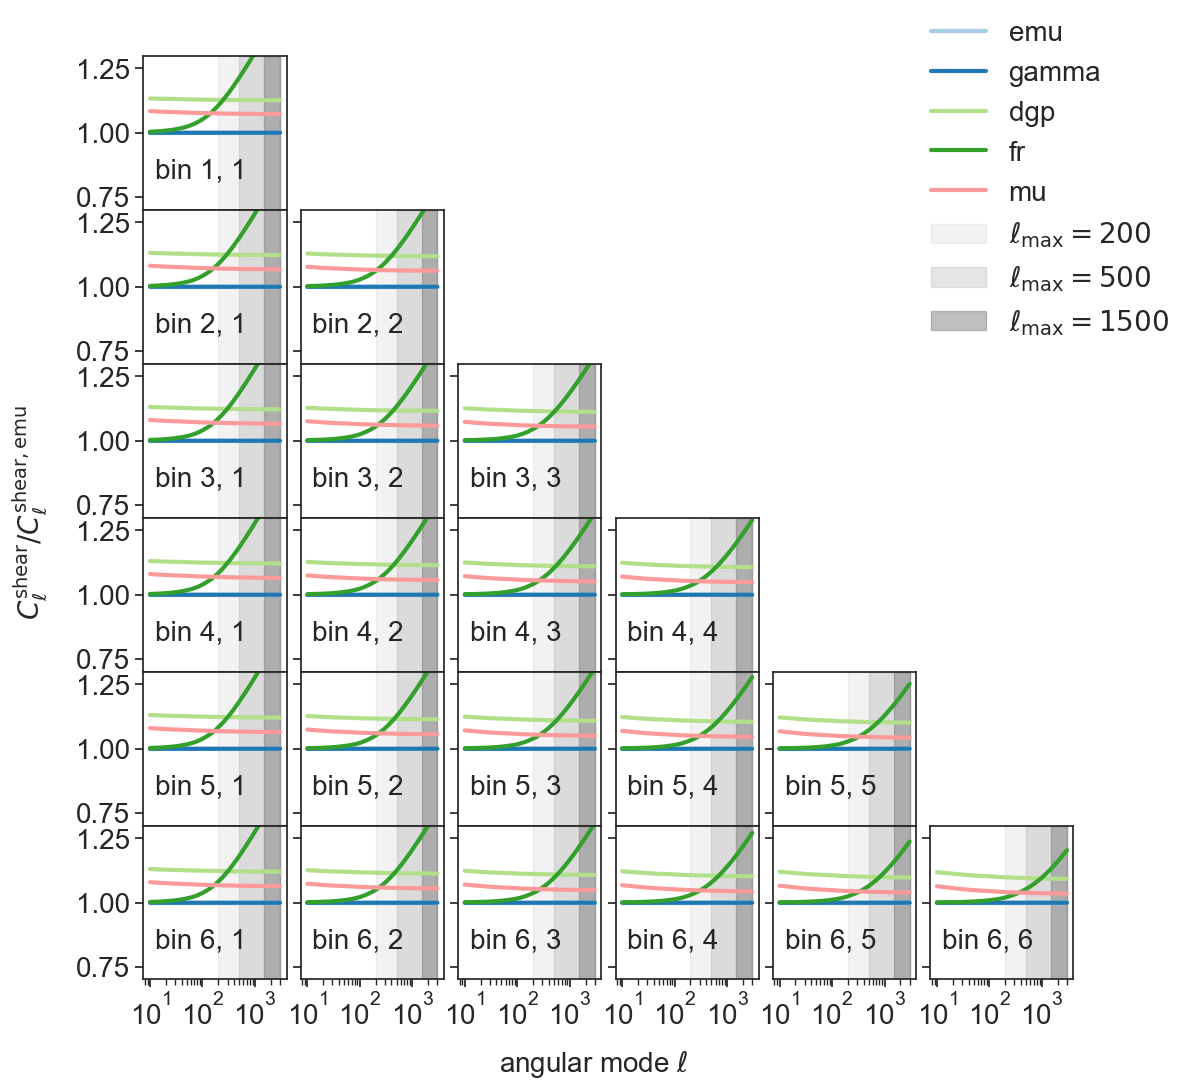

In [13]:
fig, ax = plt.subplots(nbin, nbin, figsize=(12, 12), sharey='row', sharex=True, gridspec_kw={'wspace': 0.1, 'hspace': 0})
for i in range(nbin):
    for j in range(nbin):
        if i >= j:
            for label in labels:
                ax[i,j].semilogx(ells,  cells_shear[label][('SHE', 'SHE', j+1, i+1)][0, 0]/cells_shear['emu'][('SHE', 'SHE', j+1, i+1)][0, 0])
            ax[i,j].text(.4, .2, 'bin %s, %s'%(str(i+1),(j+1)), fontsize="medium", horizontalalignment='center', transform=ax[i,j].transAxes)
            ax[i, j].axvspan(xmin=200, xmax=ells[-1], color='grey', alpha=0.1)
            ax[i, j].axvspan(xmin=500, xmax=ells[-1], color='grey', alpha=0.2)
            ax[i, j].axvspan(xmin=1500, xmax=ells[-1], color='grey', alpha=0.5)
            ax[i, j].set_ylim(0.7, 1.3)
        else:
            ax[i,j].axis('off')       
fig.text(0.03, 0.5, r'$C^{\rm shear}_{\ell}/C^{\rm shear, emu}_{\ell}$', ha='center', va='center', rotation='vertical', fontsize=20)
fig.text(0.5, 0.04, r'angular mode $\ell$', ha='center', va='center', fontsize=20)   
fig.legend(labels+['$\ell_{\\rm max}=200$', '$\ell_{\\rm max}=500$', '$\ell_{\\rm max}=1500$'],  loc='upper right', ncol=1, bbox_to_anchor=(1, 0.93), bbox_transform=fig.transFigure, fontsize=20, frameon=False, title_fontsize=20)


# Convolute with the mixing matrices.

In [14]:
mixmat = el.le3.pk_wl.mixing_matrices('mixmat_identity_5000_binned.fits')
cells_shear_pseudo = {}
ell_cell = mixmat[('SHE', 'SHE', 1, 1)].ell
print('ell: ', ell_cell)
for label in labels:
    perturbations = eval(f'linear_perturbations_{label}')
    tracer_she = ShearTracer(perturbations=perturbations, 
                                dndz=my_dndz_she_norm,
                                z = zs,
                                nuisance_params=shear_nuisance)
    twopoint_sheshe = AngularTwoPoint(tracer_she, tracer_she)
    cells_EE = twopoint_sheshe.get_pseudo_Cl(nl, linear_perturbations_emu.k, mixmat)
    print('Cl/pseudo', twopoint_sheshe.get_Cl(ell_cell, 0, linear_perturbations_emu.k)["SHE", "SHE",1, 1][0, 0]/cells_EE["SHE", "SHE",1, 1][0, 0])
    cells_shear_pseudo[label] = cells_EE

ell:  [  12.14347023   14.74638693   17.90723108   21.74559276   26.40669584
   32.0668925    38.94033545   47.28708045   57.42292539   69.73135853
   84.67806767  102.82855943  124.86955507  151.63497252  184.13747753
  223.60679775  271.53624927  329.73923607  400.41785984  486.24623623
  590.47166964  717.03751446  870.7323714  1057.37126344 1284.01564645
 1559.24057835 1893.45915518 2299.31648913 2792.16813458 3390.66106322
 4117.43916969 5000.        ]
Cl/pseudo [0.9700773  0.93603797 0.91230283 0.9067387  0.90058616 0.91190321
 0.88922001 0.88327785 0.87358666 0.86499725 0.85156434 0.84288569
 0.83614812 0.83061751 0.82909852 0.82394911 0.81740065 0.812198
 0.80818538 0.80525352 0.80145661 0.79825322 0.79488563 0.79152965
 0.78955    0.78721524 0.78467621 0.78256385 0.78078799 0.77893323
 0.77721843 0.77567505]
Cl/pseudo [0.97007731 0.9360201  0.91227128 0.90672396 0.90059199 0.91190281
 0.88921921 0.88329543 0.87362622 0.86506503 0.85156662 0.84280286
 0.83612292 0.83062099 0.82

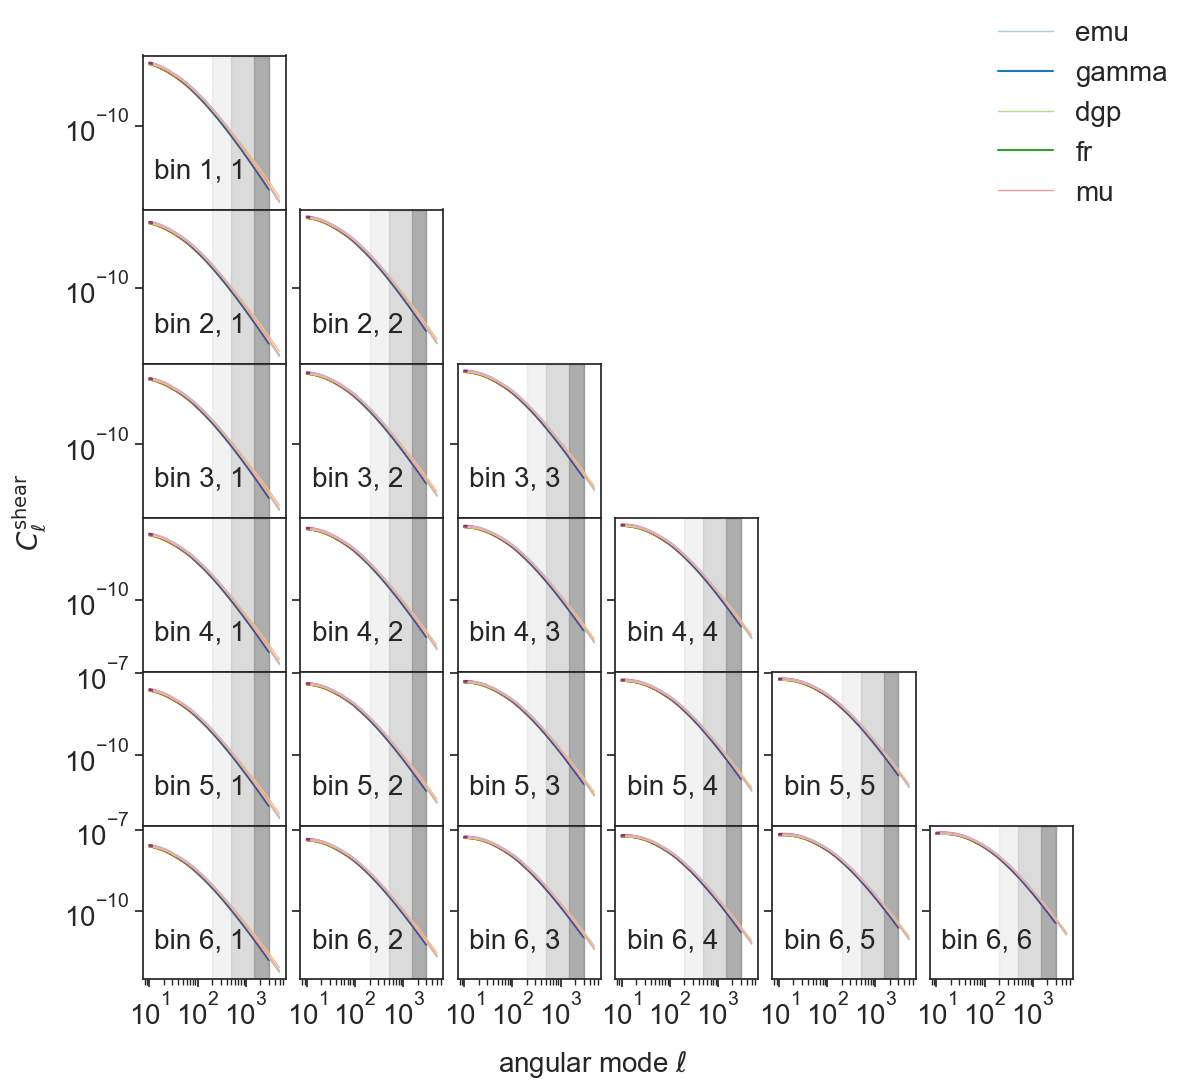

In [15]:
nbin = 6
fig, ax = plt.subplots(nbin, nbin, figsize=(12, 12), sharey='row', sharex=True, gridspec_kw={'wspace': 0.1, 'hspace': 0})
for i in range(nbin):
    for j in range(nbin):
        if i >= j:
            for label in labels:
                ax[i,j].loglog(ell_cell, cells_shear_pseudo[label]["SHE", "SHE",j+1, i+1][0, 0],
                    lw=1.,
                    zorder=4.0,
                        )
                ax[i,j].loglog(ells, cells_shear[label]["SHE", "SHE",j+1, i+1][0, 0],
                    lw=1.5,
                    zorder=2.,
                        )
            ax[i,j].text(.4, .2, 'bin %s, %s'%(str(i+1),(j+1)), fontsize="medium", horizontalalignment='center', transform=ax[i,j].transAxes)
            ax[i, j].axvspan(xmin=200, xmax=ells[-1], color='grey', alpha=0.1)
            ax[i, j].axvspan(xmin=500, xmax=ells[-1], color='grey', alpha=0.2)
            ax[i, j].axvspan(xmin=1500, xmax=ells[-1], color='grey', alpha=0.5)
        else:
            ax[i,j].axis('off')   
             
fig.text(0.03, 0.5, r'$C^{\rm shear}_{\ell}$', ha='center', va='center', rotation='vertical', fontsize=20)
fig.text(0.5, 0.04, r'angular mode $\ell$', ha='center', va='center', fontsize=20)   
fig.legend(labels,  loc='upper right', ncol=1, bbox_to_anchor=(1, 0.93), bbox_transform=fig.transFigure, fontsize=20, frameon=False, title_fontsize=20)


# Investigate the likelihood and its components

Let's look at the data first!

In [16]:
# We read with euclidlib v2025.2 (v2025.1 is also compatible)

# cells_data['SHE', 'SHE', 6, 6].shape (2, 32) (E-mode and B-mode)
# cells_data['POS', 'POS', 6, 6].shape (32)
# cells_data['POS', 'SHE', 6, 6].shape (2, 32)
cells_data = el.le3.pk_wl.angular_power_spectra('synth_cells_5000_binned.fits')

# This matrix copies the format of seaborne, that produces a full 3x2pt matrix
# shape: (3168, 3168)
full_cov=np.load('cov_Gauss_3x2pt_2D_probe_zpair_ell_2500deg2_ellmax5000_Bmode_copy.npy')

# Cutting the covariance matrix for each probe
# This should be easier with the new version of euclidlib
cov_WL = full_cov[:(21+21)*32, :(21+21)*32]

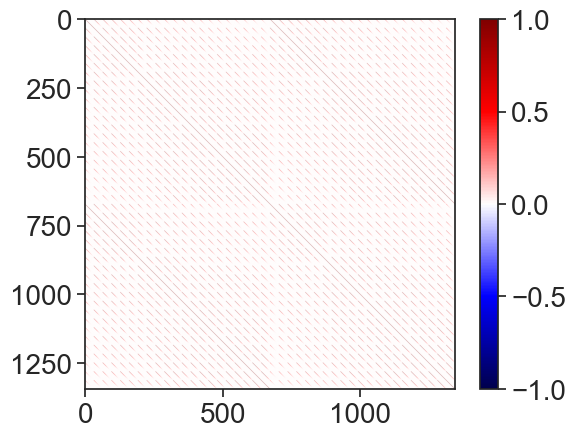

In [17]:
cmap = 'seismic'
cov = cov_WL
ndata = cov.shape[0]
pp_norm = np.zeros((ndata,ndata))
for i in range(ndata):
    for j in range(ndata):
        pp_norm[i][j] = cov[i][j]/np.sqrt(cov[i][i]*cov[j][j])   
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
im3 = ax.imshow(pp_norm, cmap=cmap, vmin=-1, vmax=1)
fig.colorbar(im3, orientation='vertical')
plt.show()

<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\e'
/var/folders/h4/nm88s1d55cb19yw7pxm0tzs40000gn/T/ipykernel_67455/324582147.py:16: SyntaxWarning: invalid escape sequence '\e'
  fig.legend(['data', 'model: linear', '$\ell_{\\rm max}=200$', '$\ell_{\\rm max}=500$', '$\ell_{\\rm max}=1500$'],  loc='upper right', ncol=1, bbox_to_anchor=(1, 0.93), bbox_transform=fig.transFigure, fontsize=20, frameon=False, title_fontsize=20)
/var/folders/h4/nm88s1d55cb19yw7pxm0tzs40000gn/T/ipykernel_67455/324582147.py:16: SyntaxWarning: invalid escape sequence '\e'
  fig.legend(['data', 'model: linear', '$\ell_{\\rm max}=200$', '$\ell_{\\rm max}=500$', '$\ell_{\\rm max}=1500$'],  loc='upper right', ncol=1, bbox_to_anchor=(1, 0.93), bbox_transform=fig.tran

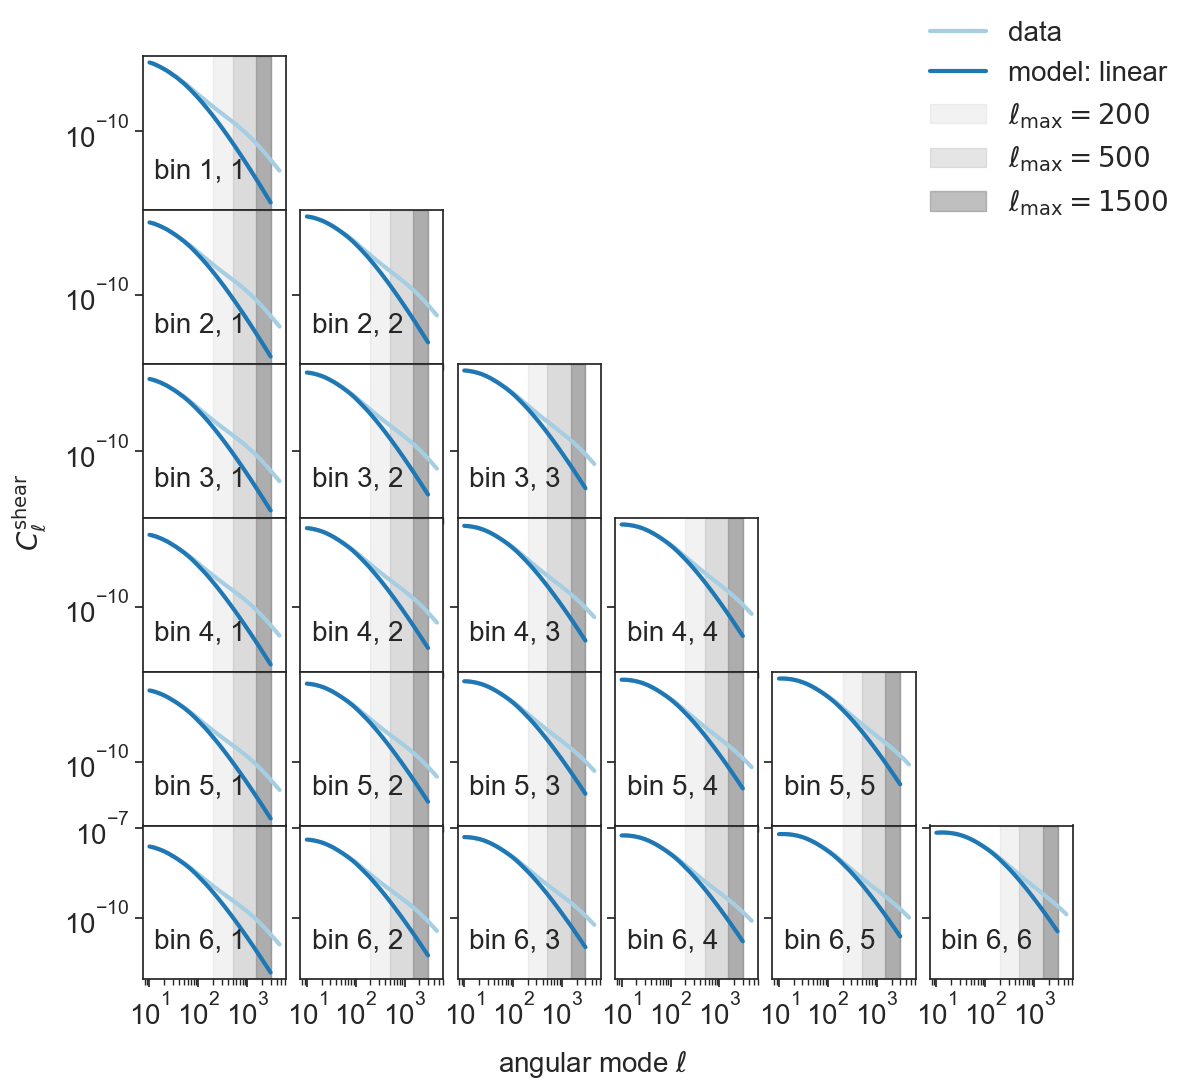

In [18]:
nbin = 6
fig, ax = plt.subplots(nbin, nbin, figsize=(12, 12), sharey='row', sharex=True, gridspec_kw={'wspace': 0.1, 'hspace': 0})
for i in range(nbin):
    for j in range(nbin):
        if i >= j:
            ax[i, j].loglog(cells_data[('SHE', 'SHE', j+1, i+1)].ell, cells_data['SHE', 'SHE', j+1, i+1][0])
            ax[i,j].loglog(ells,  cells_shear['emu'][('SHE', 'SHE', j+1, i+1)][0, 0])
            ax[i,j].text(.4, .2, 'bin %s, %s'%(str(i+1),(j+1)), fontsize="medium", horizontalalignment='center', transform=ax[i,j].transAxes)
            ax[i, j].axvspan(xmin=200, xmax=ells[-1], color='grey', alpha=0.1)
            ax[i, j].axvspan(xmin=500, xmax=ells[-1], color='grey', alpha=0.2)
            ax[i, j].axvspan(xmin=1500, xmax=ells[-1], color='grey', alpha=0.5)
        else:
            ax[i,j].axis('off')       
fig.text(0.03, 0.5, r'$C^{\rm shear}_{\ell}$', ha='center', va='center', rotation='vertical', fontsize=20)
fig.text(0.5, 0.04, r'angular mode $\ell$', ha='center', va='center', fontsize=20)   
fig.legend(['data', 'model: linear', '$\ell_{\\rm max}=200$', '$\ell_{\\rm max}=500$', '$\ell_{\\rm max}=1500$'],  loc='upper right', ncol=1, bbox_to_anchor=(1, 0.93), bbox_transform=fig.transFigure, fontsize=20, frameon=False, title_fontsize=20)

# Let's build a likelihood for linear prediction in shear-shear

In [19]:
# Import cloelike for likelihoods
from cloelike.EuclidLikelihood_WL_Cls import EuclidLikelihood_WL_Cls

/Users/s2265800/miniforge3/envs/cloe-org-env-v2026.1/lib/python3.12/site-packages/MGEmu


In [20]:
def build_data(ell_key, cov, include_pos=False, include_she=False):
    data = {
        'cells': cells_data,
        'ells': cells_data[ell_key].ell,
        'z_arr': myz,
        'cov': cov,
        'mixmat': mixmat,
    }
    if include_pos:
        data['dndz_pos'] = my_dndz_pos_norm
    if include_she:
        data['dndz_she'] = my_dndz_she_norm
    return data

#apply primitive linear cuts!
def build_settings():
    scale_cuts = {key: [10, 50] for key in cells_data}
    for key in cells_data:
        if key[:2] == ('SHE', 'SHE'):
            scale_cuts[key] = [scale_cuts[key], [0, 0]]
    return {'n_ell_bins': 32, 'scale_cuts': scale_cuts}

# Build each dataset with correct dndz components
data_WL     = build_data(('SHE', 'SHE', 1, 1), cov_WL,  include_she=True)

# Settings (same for all, built from cells_data structure)
settings_WL     = build_settings()


In [21]:
import time
print(f"\n📊 WL loglike HMcodeEmu:")
data, settings = (data_WL, settings_WL)
start = time.time()
cls_hmcode = EuclidLikelihood_WL_Cls(
    data=data,
    settings=settings,
    Background=CAMBBackground,
    LinPerturbations=HMemuLinearPerturbations,
    NonLinPerturbations=HMemuNonLinearPerturbations,
)
end = time.time()

print(f"⏱️ Time elapsed: {end - start:.3f} seconds")

print(f"\n📊 WL loglike MGrowth:")
data, settings = (data_WL, settings_WL)
start = time.time()
cls_mgrowth_gamma = EuclidLikelihood_WL_Cls(
    data=data,
    settings=settings,
    Background=CAMBBackground,
    LinPerturbations=MGrowthLinearPerturbations,
    LinPerturbationsBase=HMemuLinearPerturbations,
    NonLinPerturbations=None,
    gravity_model='gammaz'
)
end = time.time()
print('for gamma:')
print(f"⏱️ Time elapsed: {end - start:.3f} seconds")
start = time.time()
cls_mgrowth_dgp = EuclidLikelihood_WL_Cls(
    data=data,
    settings=settings,
    Background=CAMBBackground,
    LinPerturbations=MGrowthLinearPerturbations,
    LinPerturbationsBase=HMemuLinearPerturbations,
    NonLinPerturbations=None,
    gravity_model='dgp'
)
end = time.time()
print('for dgp:')
print(f"⏱️ Time elapsed: {end - start:.3f} seconds")
start = time.time()
cls_mgrowth_fofr = EuclidLikelihood_WL_Cls(
    data=data,
    settings=settings,
    Background=CAMBBackground,
    LinPerturbations=MGrowthLinearPerturbations,
    LinPerturbationsBase=HMemuLinearPerturbations,
    NonLinPerturbations=None,
    gravity_model='fr'
)
end = time.time()
print('for fr:')
print(f"⏱️ Time elapsed: {end - start:.3f} seconds")
start = time.time()
cls_mgrowth_musigma = EuclidLikelihood_WL_Cls(
    data=data,
    settings=settings,
    Background=CAMBBackground,
    LinPerturbations=MGrowthLinearPerturbations,
    LinPerturbationsBase=HMemuLinearPerturbations,
    NonLinPerturbations=None,
    gravity_model='musigma-de'
)
end = time.time()
print('for musigma-de:')
print(f"⏱️ Time elapsed: {end - start:.3f} seconds")



📊 WL loglike HMcodeEmu:
⏱️ Time elapsed: 0.015 seconds

📊 WL loglike MGrowth:
for gamma:
⏱️ Time elapsed: 0.012 seconds
for dgp:
⏱️ Time elapsed: 0.013 seconds
for fr:
⏱️ Time elapsed: 0.013 seconds
for musigma-de:
⏱️ Time elapsed: 0.014 seconds


# Explore likelihoods as a function of extended parameters
First test the "emu"-model, which corresponds to the HMcode2020Emu model with the fiducial values used to compute the synthetic data. The likelihood must be close to 0 (spoilers: it is)!

In [23]:
import yaml
config_file = 'params_model_shear.yaml'
with open(config_file, "r") as file_in:
    params_dic = yaml.safe_load(file_in)
params_priors = params_dic
params_model = [par for par in params_dic if params_dic[par]['type'] != 'F']
params_fixed = {par: params_dic[par]['p0'] for par in params_dic if params_dic[par]['type'] == 'F'}

default_pars = {par_i: params_priors[par_i]['p0'] for par_i in params_priors.keys()}
default_pars = params_fixed | default_pars
default_pars['Omega_b0'] = default_pars['ombh2'] / (default_pars['H0']/100)**2
default_pars['As'] = np.exp(default_pars['logAs'])*1e-10
cls_hmcode.loglike(default_pars)

np.float64(-0.0008513288240803998)

<>:26: SyntaxWarning: invalid escape sequence '\g'
<>:30: SyntaxWarning: invalid escape sequence '\g'
<>:26: SyntaxWarning: invalid escape sequence '\g'
<>:30: SyntaxWarning: invalid escape sequence '\g'
/var/folders/h4/nm88s1d55cb19yw7pxm0tzs40000gn/T/ipykernel_67455/411995245.py:26: SyntaxWarning: invalid escape sequence '\g'
  plt.axvline(0.545, color='k', linestyle='--', label='Reference $\gamma$')
/var/folders/h4/nm88s1d55cb19yw7pxm0tzs40000gn/T/ipykernel_67455/411995245.py:30: SyntaxWarning: invalid escape sequence '\g'
  plt.title('Likelihood scan over $\gamma$ for shear')



🔄 Scanning over gamma


mgrowth: 100%|████████████████████████████████| 128/128 [00:15<00:00,  8.43it/s]


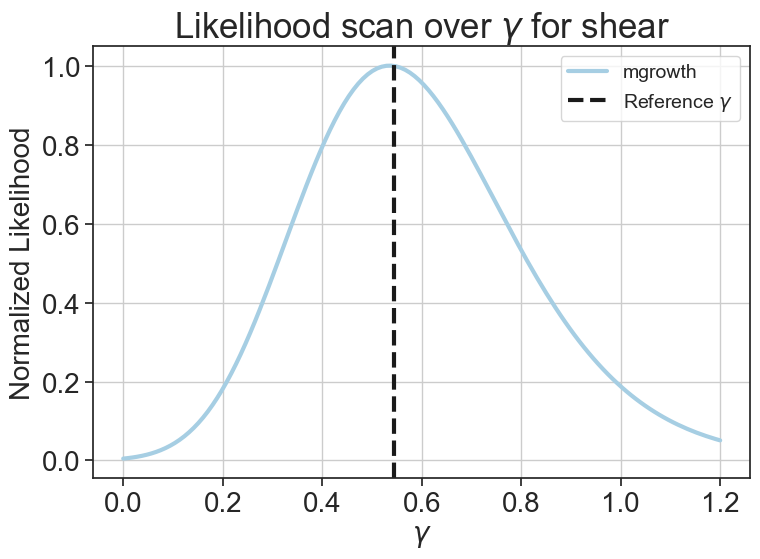

In [24]:
## Exploration of the parameter space
from tqdm import tqdm

# Define the range of Omega_cdm0 values to scan
gamma_vals = np.linspace(0., 1.2, 128)

# Prepare the figure
plt.figure(figsize=(8,6))

print(f"\n🔄 Scanning over gamma")
likelihood_curve = []

for gamma_i in tqdm(gamma_vals, desc=f"mgrowth", ncols=80):
    # Compute log-likelihood
    default_pars['gamma0'] = gamma_i
    ll = cls_mgrowth_gamma.loglike(default_pars)
    likelihood_curve.append(ll)


# Convert log-likelihoods to likelihoods (exp) and normalize
likelihood_curve = np.exp(likelihood_curve - np.max(likelihood_curve))

# Plot
plt.plot(gamma_vals, likelihood_curve, label='mgrowth')
# Reference vertical line (e.g. Planck best-fit)
plt.axvline(0.545, color='k', linestyle='--', label='Reference $\gamma$')

plt.xlabel(r'$\gamma$')
plt.ylabel('Normalized Likelihood')
plt.title('Likelihood scan over $\gamma$ for shear')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<>:22: SyntaxWarning: invalid escape sequence '\O'
<>:26: SyntaxWarning: invalid escape sequence '\O'
<>:22: SyntaxWarning: invalid escape sequence '\O'
<>:26: SyntaxWarning: invalid escape sequence '\O'
/var/folders/h4/nm88s1d55cb19yw7pxm0tzs40000gn/T/ipykernel_67455/3815698254.py:22: SyntaxWarning: invalid escape sequence '\O'
  plt.axvline(0., color='k', linestyle='--', label='Reference $\Omega_{rc}$')
/var/folders/h4/nm88s1d55cb19yw7pxm0tzs40000gn/T/ipykernel_67455/3815698254.py:26: SyntaxWarning: invalid escape sequence '\O'
  plt.title('Likelihood scan over $\Omega_{rc}$ for shear')



🔄 Scanning over dgp


mgrowth: 100%|████████████████████████████████| 128/128 [00:08<00:00, 15.73it/s]


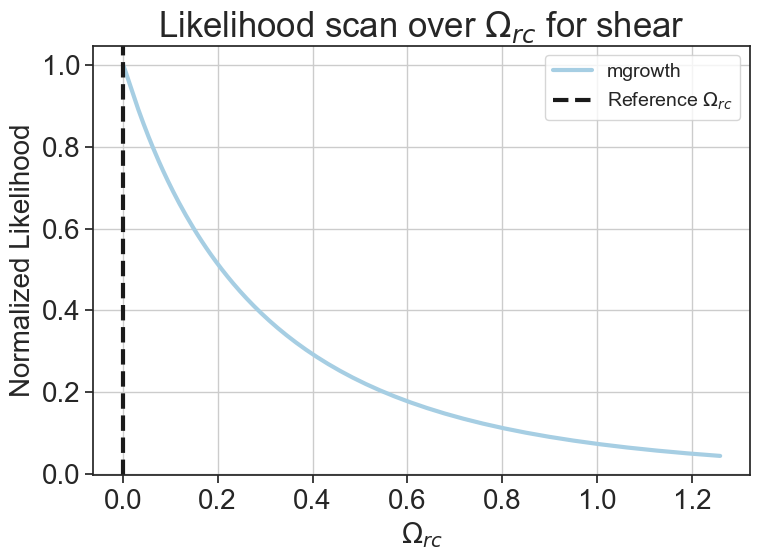

In [25]:
logomega_rc_vals = np.linspace(-3., 0.1, 128)

# Prepare the figure
plt.figure(figsize=(8,6))

print(f"\n🔄 Scanning over dgp")
likelihood_curve = []

for val_i in tqdm(logomega_rc_vals, desc=f"mgrowth", ncols=80):
    # Compute log-likelihood
    default_pars['omega_rc'] = 10**val_i
    ll = cls_mgrowth_dgp.loglike(default_pars)
    likelihood_curve.append(ll)


# Convert log-likelihoods to likelihoods (exp) and normalize
likelihood_curve = np.exp(likelihood_curve - np.max(likelihood_curve))

# Plot
plt.plot(10**logomega_rc_vals, likelihood_curve, label='mgrowth')
# Reference vertical line (e.g. Planck best-fit)
plt.axvline(0., color='k', linestyle='--', label='Reference $\Omega_{rc}$')

plt.xlabel(r'$\Omega_{rc}$')
plt.ylabel('Normalized Likelihood')
plt.title('Likelihood scan over $\Omega_{rc}$ for shear')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


🔄 Scanning over fofr


mgrowth: 100%|████████████████████████████████| 128/128 [01:01<00:00,  2.09it/s]


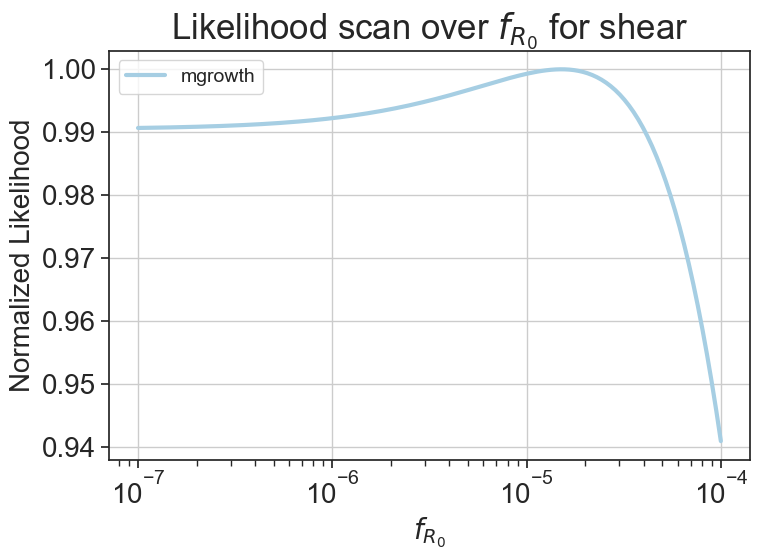

In [26]:
logfr0_rc_vals = np.linspace(-7., -4., 128)

# Prepare the figure
plt.figure(figsize=(8,6))

print(f"\n🔄 Scanning over fofr")
likelihood_curve = []

for val_i in tqdm(logfr0_rc_vals, desc=f"mgrowth", ncols=80):
    # Compute log-likelihood
    default_pars['fr0'] = 10**val_i
    ll = cls_mgrowth_fofr.loglike(default_pars)
    likelihood_curve.append(ll)


# Convert log-likelihoods to likelihoods (exp) and normalize
likelihood_curve = np.exp(likelihood_curve - np.max(likelihood_curve))

# Plot
plt.semilogx(10**logfr0_rc_vals, likelihood_curve, label='mgrowth')

plt.xlabel(r'$f_{R_0}$')
plt.ylabel('Normalized Likelihood')
plt.title('Likelihood scan over $f_{R_0}$ for shear')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\S'
<>:25: SyntaxWarning: invalid escape sequence '\L'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\S'
<>:25: SyntaxWarning: invalid escape sequence '\L'
<>:28: SyntaxWarning: invalid escape sequence '\m'
/var/folders/h4/nm88s1d55cb19yw7pxm0tzs40000gn/T/ipykernel_67455/2187233434.py:23: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(vals, likelihood_curve_mu, label='mgrowth: $\mu$')
/var/folders/h4/nm88s1d55cb19yw7pxm0tzs40000gn/T/ipykernel_67455/2187233434.py:24: SyntaxWarning: invalid escape sequence '\S'
  plt.plot(vals_sigma, likelihood_curve_sigma, label='mgrowth: $\Sigma$')
/var/folders/h4/nm88s1d55cb19yw7pxm0tzs40000gn/T/ipykernel_67455/2187233434.py:25: SyntaxWarning: invalid escape sequence '\L'
  plt.axvline(0., color='k', linestyle='--', label='Reference $\Lambda$CDM'


🔄 Scanning over mu-Sigma


mgrowth: 100%|████████████████████████████████| 128/128 [00:08<00:00, 15.74it/s]


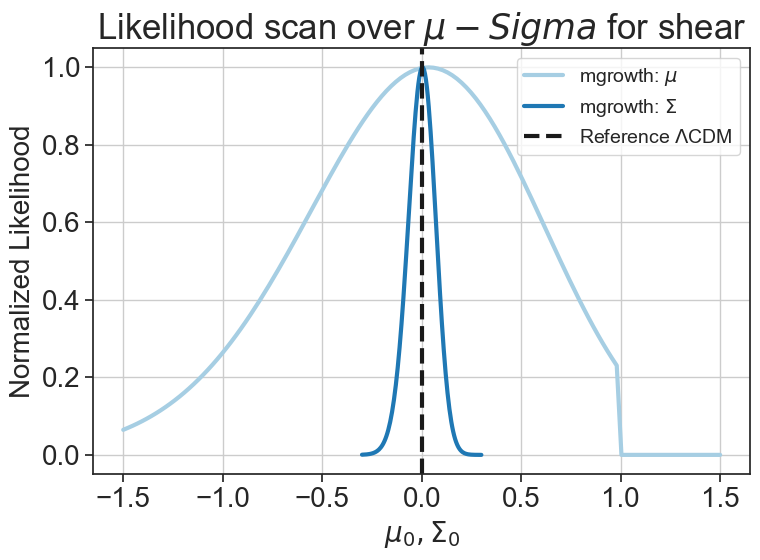

In [ ]:
vals = np.linspace(-1.5, 1.5, 128)
vals_sigma = np.linspace(-0.3, 0.3, 128)
# Prepare the figure
plt.figure(figsize=(8,6))
# Note that likelihood is computed for mu0 and sigma0 under the condition
# mu0< 2sigma0 + 1
print(f"\n🔄 Scanning over mu-Sigma")
likelihood_curve = []

for val_i in tqdm(vals, desc=f"mgrowth", ncols=80):
    default_pars['mu0'] = val_i
    default_pars['sigma0'] = 0.
    ll = cls_mgrowth_musigma.loglike(default_pars)
    likelihood_curve.append(ll)
likelihood_curve_mu = np.exp(likelihood_curve - np.max(likelihood_curve))
likelihood_curve = []
for val_i in tqdm(vals_sigma, desc=f"mgrowth", ncols=80):
    default_pars['sigma0'] = val_i
    default_pars['mu0'] = 0.
    ll = cls_mgrowth_musigma.loglike(default_pars)
    likelihood_curve.append(ll)
likelihood_curve_sigma = np.exp(likelihood_curve - np.max(likelihood_curve))

plt.plot(vals, likelihood_curve_mu, label='mgrowth: $\mu$')
plt.plot(vals_sigma, likelihood_curve_sigma, label='mgrowth: $\Sigma$')
plt.axvline(0., color='k', linestyle='--', label='Reference $\Lambda$CDM')
plt.xlabel(r'$\mu_0, \Sigma_0$')
plt.ylabel('Normalized Likelihood')
plt.title('Likelihood scan over $\mu-Sigma$ for shear')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# How do we decide the linear scale-cuts for these models?

All scale-independent linear modification from above have a clear ΛCDM limit. Hence, we just find when the nonlinear power spectrum from the synthetic data starts to deviate from its linear behaviour. For this we use $\chi^2$ stastictics like DES. WARNING: for now the synthetic data is noiseless so it does not make a lot of sense! Once scale-cuts are decided we can run chains and assess the behaviour of the posterior distribution in each model.



As a guideline, we first compute the correspondence of $k_{\rm max} = [0.1, 0.3] ~h/{\rm Mpc}$ to $\ell_{\rm max}$ using the mod-redshift which corresponds to the maximum of the lensing kernel.

$$
\ell_{\rm max} = k_{\rm max} \frac{\chi(z_{\rm mod})}{1+z_{\rm mod}}
$$

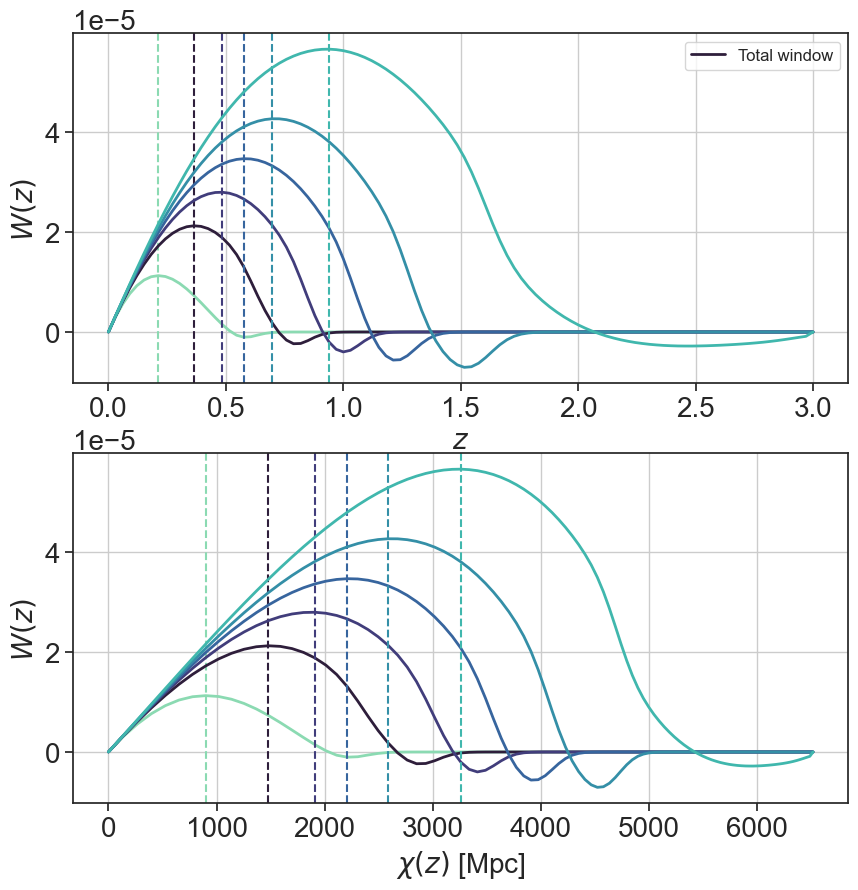

In [28]:
z_mod = []
comdis_mod = []
colors = sns.color_palette("mako", len(nz_heracles.keys()))
# Create the figure
fig, axs = plt.subplots(2, 1, figsize=(10, 10))
for i in range(6):
    # Plot the window
    axs[0].plot(perturbations.z, 
             tracer_she.get_window(perturbations.z)[i, :], 
             linewidth=2, 
             color=colors[i-1], 
             label=f'Total window' if i == 1 else "")
    ind = np.argmax(tracer_she.get_window(perturbations.z)[i, :])
    zmod = perturbations.z[ind]
    z_mod.append(zmod)
    axs[0].axvline(x=zmod, color=colors[i-1], linewidth=1.5, linestyle='--')

    axs[1].plot(perturbations.background.comoving_distance((perturbations.z)), 
             tracer_she.get_window(perturbations.z)[i, :], 
             linewidth=2, 
             color=colors[i-1], 
             label=f'Total window' if i == 1 else "")
    comdismod = perturbations.background.comoving_distance((perturbations.z))[ind]
    comdis_mod.append(comdismod)
    axs[1].axvline(x=comdismod, color=colors[i-1], linewidth=1.5, linestyle='--')

    
# Label the axes
axs[0].set_xlabel(r'$z$');axs[1].set_xlabel(r'$\chi(z)$ [Mpc]')
axs[0].set_ylabel(r'$W(z)$');axs[1].set_ylabel(r'$W(z)$')

# Add the legend and grid
axs[0].legend(fontsize=12, loc='upper right')
axs[0].grid(True);axs[1].grid(True)

# Show the plot
plt.show()


In [31]:
def from_kmax_to_lmax(kmax):
    print(f'for kmax = {kmax:.2f} 1/Mpc')
    lmax_list = [kmax * comdis / (1 + z) for comdis, z in zip(comdis_mod, z_mod)]
    for i, lmax in enumerate(lmax_list, start=1):
        print(f'bin {i} - lmax = {lmax:.2f}')
    return lmax_list

lmax_0p1 = from_kmax_to_lmax(perturbations.background.h * 0.1)
lmax_0p3 = from_kmax_to_lmax(perturbations.background.h * 0.3)
lmax_0p4 = from_kmax_to_lmax(perturbations.background.h * 0.4)
lmax_0p5 = from_kmax_to_lmax(perturbations.background.h * 0.5)
lmax_0p7 = from_kmax_to_lmax(perturbations.background.h * 0.7)
lmax_0p9 = from_kmax_to_lmax(perturbations.background.h * 0.9)
lmax_1p5 = from_kmax_to_lmax(perturbations.background.h * 1.5)

for kmax = 0.07 1/Mpc
bin 1 - lmax = 49.74
bin 2 - lmax = 72.75
bin 3 - lmax = 86.14
bin 4 - lmax = 93.98
bin 5 - lmax = 102.12
bin 6 - lmax = 112.62
for kmax = 0.20 1/Mpc
bin 1 - lmax = 149.22
bin 2 - lmax = 218.25
bin 3 - lmax = 258.43
bin 4 - lmax = 281.93
bin 5 - lmax = 306.35
bin 6 - lmax = 337.86
for kmax = 0.27 1/Mpc
bin 1 - lmax = 198.97
bin 2 - lmax = 291.00
bin 3 - lmax = 344.57
bin 4 - lmax = 375.91
bin 5 - lmax = 408.47
bin 6 - lmax = 450.48
for kmax = 0.34 1/Mpc
bin 1 - lmax = 248.71
bin 2 - lmax = 363.75
bin 3 - lmax = 430.71
bin 4 - lmax = 469.88
bin 5 - lmax = 510.58
bin 6 - lmax = 563.09
for kmax = 0.47 1/Mpc
bin 1 - lmax = 348.19
bin 2 - lmax = 509.25
bin 3 - lmax = 602.99
bin 4 - lmax = 657.84
bin 5 - lmax = 714.82
bin 6 - lmax = 788.33
for kmax = 0.60 1/Mpc
bin 1 - lmax = 447.67
bin 2 - lmax = 654.75
bin 3 - lmax = 775.28
bin 4 - lmax = 845.79
bin 5 - lmax = 919.05
bin 6 - lmax = 1013.57
for kmax = 1.01 1/Mpc
bin 1 - lmax = 746.12
bin 2 - lmax = 1091.25
bin 3 - lmax

Let's compute $\chi^2=-2\ln(\mathcal{L})$ for these scale-cuts between $C_{\ell}$ with linear and nonlinear power spectrum with the given covariance.

In [32]:
def setup(lmax):

    cells_shear_scalecuts = {
        ('SHE', 'SHE', 1, 1): [[10, lmax[0]], [0, 0]],
        ('SHE', 'SHE', 1, 2): [[10, lmax[0]], [0, 0]],
        ('SHE', 'SHE', 1, 3): [[10, lmax[0]], [0, 0]],
        ('SHE', 'SHE', 1, 4): [[10, lmax[0]], [0, 0]],
        ('SHE', 'SHE', 1, 5): [[10, lmax[0]], [0, 0]],
        ('SHE', 'SHE', 1, 6): [[10, lmax[0]], [0, 0]],

        ('SHE', 'SHE', 2, 2): [[10, lmax[1]], [0, 0]],
        ('SHE', 'SHE', 2, 3): [[10, lmax[1]], [0, 0]],
        ('SHE', 'SHE', 2, 4): [[10, lmax[1]], [0, 0]],
        ('SHE', 'SHE', 2, 5): [[10, lmax[1]], [0, 0]],
        ('SHE', 'SHE', 2, 6): [[10, lmax[1]], [0, 0]],

        ('SHE', 'SHE', 3, 3): [[10, lmax[2]], [0, 0]],
        ('SHE', 'SHE', 3, 4): [[10, lmax[2]], [0, 0]],
        ('SHE', 'SHE', 3, 5): [[10, lmax[2]], [0, 0]],
        ('SHE', 'SHE', 3, 6): [[10, lmax[2]], [0, 0]],

        ('SHE', 'SHE', 4, 4): [[10, lmax[3]], [0, 0]],
        ('SHE', 'SHE', 4, 5): [[10, lmax[3]], [0, 0]],
        ('SHE', 'SHE', 4, 6): [[10, lmax[3]], [0, 0]],

        ('SHE', 'SHE', 5, 5): [[10, lmax[4]], [0, 0]],
        ('SHE', 'SHE', 5, 6): [[10, lmax[4]], [0, 0]],

        ('SHE', 'SHE', 6, 6): [[10, lmax[5]], [0, 0]]
    }


    # Build each dataset with correct dndz components
    data_WL     = build_data(('SHE', 'SHE', 1, 1), cov_WL,  include_she=True)

    # Settings (same for all, built from cells_data structure)
    settings_WL     = {'n_ell_bins': 32, 'scale_cuts': cells_shear_scalecuts}
    return data_WL, settings_WL

In [33]:
# We take mu-Sigma, since it belongs to the tier-1 category, but any other model in its LCDM limit can be used
data_0p1, settings_0p1 = setup(lmax_0p1)
cls_mgrowth_musigma_0p1 = EuclidLikelihood_WL_Cls(
    data=data_0p1,
    settings=settings_0p1,
    Background=CAMBBackground,
    LinPerturbations=MGrowthLinearPerturbations,
    LinPerturbationsBase=HMemuLinearPerturbations,
    NonLinPerturbations=None,
    gravity_model='musigma-de'
)

data_0p3, settings_0p3 = setup(lmax_0p3)
cls_mgrowth_musigma_0p3 = EuclidLikelihood_WL_Cls(
    data=data_0p3,
    settings=settings_0p3,
    Background=CAMBBackground,
    LinPerturbations=MGrowthLinearPerturbations,
    LinPerturbationsBase=HMemuLinearPerturbations,
    NonLinPerturbations=None,
    gravity_model='musigma-de'
)

data_0p4, settings_0p4 = setup(lmax_0p4)
cls_mgrowth_musigma_0p4 = EuclidLikelihood_WL_Cls(
    data=data_0p4,
    settings=settings_0p4,
    Background=CAMBBackground,
    LinPerturbations=MGrowthLinearPerturbations,
    LinPerturbationsBase=HMemuLinearPerturbations,
    NonLinPerturbations=None,
    gravity_model='musigma-de'
)

In [34]:
default_pars['mu0'] = 0.
default_pars['sigma0'] = 0.
print('kmax = 0.1 h/Mpc:  chi2 = ', -2.*cls_mgrowth_musigma_0p1.loglike(default_pars), ' / ', len(cls_mgrowth_musigma_0p1.masked_theory_vector))
print('kmax = 0.3 h/Mpc:  chi2 = ', -2.*cls_mgrowth_musigma_0p3.loglike(default_pars), ' / ', len(cls_mgrowth_musigma_0p3.masked_theory_vector))
print('kmax = 0.4 h/Mpc:  chi2 = ', -2.*cls_mgrowth_musigma_0p4.loglike(default_pars), ' / ', len(cls_mgrowth_musigma_0p4.masked_theory_vector))

kmax = 0.1 h/Mpc:  chi2 =  0.3509252413832451  /  214
kmax = 0.3 h/Mpc:  chi2 =  125.0323945981351  /  337
kmax = 0.4 h/Mpc:  chi2 =  422.2444150348946  /  362


<>:19: SyntaxWarning: invalid escape sequence '\L'
<>:22: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\L'
<>:22: SyntaxWarning: invalid escape sequence '\m'
/var/folders/h4/nm88s1d55cb19yw7pxm0tzs40000gn/T/ipykernel_67455/2290066857.py:19: SyntaxWarning: invalid escape sequence '\L'
  plt.axvline(0., color='k', linestyle='--', label='Reference $\Lambda$CDM')
/var/folders/h4/nm88s1d55cb19yw7pxm0tzs40000gn/T/ipykernel_67455/2290066857.py:22: SyntaxWarning: invalid escape sequence '\m'
  plt.title('Likelihood scan over $\mu$ for shear')



🔄 Scanning over mu


mgrowth kmax=0.4: 100%|███████████████████████| 128/128 [00:05<00:00, 22.48it/s]


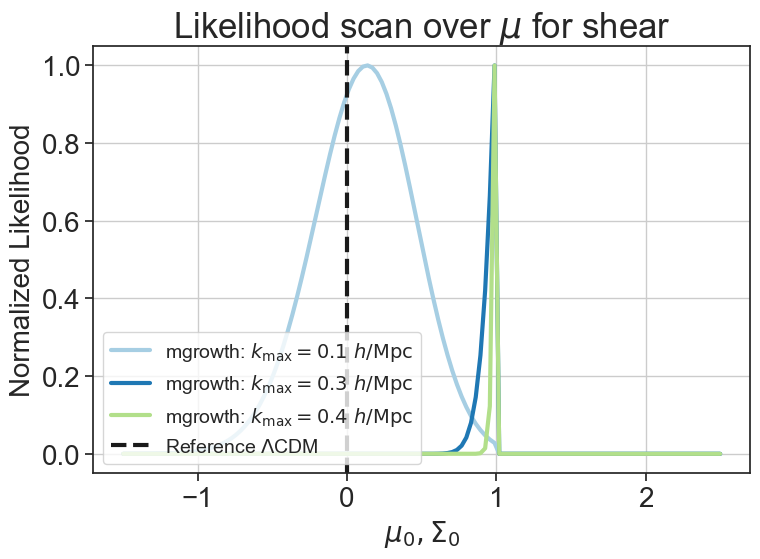

In [35]:
vals = np.linspace(-1.5, 2.5, 128)
kmax_values = [0.1, 0.3, 0.4]
cls_objects = [cls_mgrowth_musigma_0p1, cls_mgrowth_musigma_0p3, cls_mgrowth_musigma_0p4]
likelihood_curves = {}

plt.figure(figsize=(8, 6))
print(f"\n🔄 Scanning over mu")

for kmax, cls_obj in zip(kmax_values, cls_objects):
    likelihood_curve = []
    for val_i in tqdm(vals, desc=f"mgrowth kmax={kmax}", ncols=80):
        default_pars['mu0'] = val_i
        default_pars['sigma0'] = 0.
        ll = cls_obj.loglike(default_pars)
        likelihood_curve.append(ll)
    likelihood_curves[kmax] = np.exp(likelihood_curve - np.max(likelihood_curve))
    plt.plot(vals, likelihood_curves[kmax], label=f'mgrowth: $k_{{\\rm max}}={kmax}~h/{{\\rm Mpc}}$')

plt.axvline(0., color='k', linestyle='--', label='Reference $\Lambda$CDM')
plt.xlabel(r'$\mu_0, \Sigma_0$')
plt.ylabel('Normalized Likelihood')
plt.title('Likelihood scan over $\mu$ for shear')
plt.legend(loc='lower left')
plt.grid(True)
plt.tight_layout()
plt.show()
